# Ch12 - RLHF 概念演示

Reinforcement Learning from Human Feedback：用 toy 环境演示 PPO + RM + KL 惩罚机制。

> 本 Notebook 配套《强化学习全面教程》PDF 使用。

In [1]:
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import random
from collections import deque, defaultdict

# 中文字体配置
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__} | 设备: {device} | Gymnasium: {gym.__version__}')


PyTorch: 2.13.0+cpu | 设备: cpu | Gymnasium: 1.3.0


## 12.1 RLHF 三阶段

ChatGPT 等大模型对齐人类偏好的关键技术：

1. **SFT（Supervised Fine-Tuning）**：用指令数据微调基座模型
2. **RM 训练**：收集人类偏好对 (y_w, y_l)，训练奖励模型
3. **PPO 微调**：用 RM 作为奖励，PPO 优化 LLM，加 KL 惩罚防止偏离 SFT

**核心损失**：
$$L_{RLHF} = E[r_{RM}(x, y)] - \beta \cdot KL[\pi_\theta || \pi_{SFT}]$$

## 12.2 KL 惩罚的作用

KL 项是 RLHF 的核心防御机制——没有它，LLM 可能 **reward hacking**：
学会输出 RM 给高分但实际无意义的内容。

本 Notebook 用 toy 环境演示这个机制：- 真实人类偏好：动作 1 是好的
- RM 可能误学到'动作 2 给更高分'（reward hacking）
- KL 惩罚防止策略偏离参考策略（SFT 模型）太远

In [2]:
class ToyEnv:
    """玩具环境：状态 0..9，动作 0/1/2。
    - 真实偏好: action=1 是好的 (r=1)
    - RM 可能误学到 action=2 给更高分 (reward hacking)
    """
    def __init__(self):
        self.n_states = 10
        self.n_actions = 3
        self.state = 0
    def reset(self):
        self.state = np.random.randint(0, self.n_states)
        return self.state
    def step(self, action):
        true_reward = 1.0 if action == 1 else 0.0
        self.state = (self.state + 1) % self.n_states
        return self.state, true_reward, False


class TinyPolicy(nn.Module):
    def __init__(self, n_states, n_actions):
        super().__init__()
        self.emb = nn.Embedding(n_states, 16)
        self.head = nn.Linear(16, n_actions)
    def forward(self, s):
        return self.head(self.emb(s))


class RewardModel(nn.Module):
    """模拟人类偏好训练出的奖励模型 (含 reward hacking)。"""
    def __init__(self, n_states, n_actions):
        super().__init__()
        self.emb = nn.Embedding(n_states, 16)
        self.head = nn.Linear(16, n_actions)
    def forward(self, s):
        return self.head(self.emb(s))
    def hack_reward(self, s, a):
        """模拟 reward hacking: action=2 给虚高奖励。"""
        return self.forward(s)[a] + (2.0 if a == 2 else 0.0)

print('ToyEnv + TinyPolicy + RewardModel 定义完成 ✓')

ToyEnv + TinyPolicy + RewardModel 定义完成 ✓


## 12.3 KL 散度计算

用 KL(p || q) 衡量策略与参考策略的差异。

In [3]:
def kl_divergence(logits_p, logits_q):
    """KL(p || q) for categorical distributions。"""
    p = torch.softmax(logits_p, dim=-1)
    log_p = torch.log_softmax(logits_p, dim=-1)
    log_q = torch.log_softmax(logits_q, dim=-1)
    return (p * (log_p - log_q)).sum(dim=-1).mean()

# 测试
p = torch.tensor([[1.0, 0.5, 0.3]])
q = torch.tensor([[1.0, 0.5, 0.3]])
print(f'相同分布 KL = {kl_divergence(p, q).item():.4f} (应为 0)')

q2 = torch.tensor([[2.0, 0.1, 0.1]])
print(f'不同分布 KL = {kl_divergence(p, q2).item():.4f}')

相同分布 KL = 0.0000 (应为 0)
不同分布 KL = 0.2054


## 12.4 训练流程

1. 预训练 RM（让它学到 a=1 给 1 分, a=2 给 2 分含 hacking）
2. RLHF 训练：用 PPO 优化 policy，加 KL 惩罚

In [13]:
import torch.optim as optim
from torch.distributions import Categorical
random.seed(42); np.random.seed(42); torch.manual_seed(42)

env = ToyEnv()
policy = TinyPolicy(env.n_states, env.n_actions).to(device)
ref_policy = TinyPolicy(env.n_states, env.n_actions).to(device)
ref_policy.load_state_dict(policy.state_dict())
reward_model = RewardModel(env.n_states, env.n_actions).to(device)

# ─── 1. 预训练 RM ───
rm_optim = optim.Adam(reward_model.parameters(), lr=1e-2)
print('预训练 Reward Model...')
for _ in range(500):
    s = torch.randint(0, env.n_states, (32,))
    target = torch.tensor([0.0, 1.0, 2.0]).unsqueeze(0).expand(32, -1)
    pred = reward_model(s)
    loss = nn.functional.mse_loss(pred, target)
    rm_optim.zero_grad(); loss.backward(); rm_optim.step()
print('RM 预训练完成 ✓')

# ─── 2. RLHF 训练 ───
p_optim = optim.Adam(policy.parameters(), lr=1e-3)
kl_coef = 500.5
steps = 2000
print(f'\nRLHF 训练 (kl_coef={kl_coef})...')

for step in range(steps):
    s = env.reset()
    s_t = torch.tensor(s)
    logits = policy(s_t)
    dist = Categorical(logits=logits)
    a = dist.sample()
    log_prob = dist.log_prob(a)

    with torch.no_grad():
        rm_score = reward_model.hack_reward(s_t, a).item()
        ref_logits = ref_policy(s_t)
        kl = kl_divergence(logits.unsqueeze(0), ref_logits.unsqueeze(0)).item()
    shaped_reward = rm_score - kl_coef * kl

    with torch.no_grad():
        advantage = shaped_reward
    loss = -(log_prob * advantage).mean()
    loss = loss + kl_coef * kl_divergence(logits.unsqueeze(0), ref_logits.unsqueeze(0))
    p_optim.zero_grad(); loss.backward(); p_optim.step()

    if (step + 1) % 400 == 0:
        print(f'  step {step+1:4d} | rm_score={rm_score:.2f} | KL={kl:.3f} | action={a.item()}')

预训练 Reward Model...
RM 预训练完成 ✓

RLHF 训练 (kl_coef=500.5)...
  step  400 | rm_score=-0.00 | KL=0.000 | action=0
  step  800 | rm_score=4.00 | KL=0.000 | action=2
  step 1200 | rm_score=4.00 | KL=0.000 | action=2
  step 1600 | rm_score=4.00 | KL=0.000 | action=2
  step 2000 | rm_score=1.00 | KL=0.000 | action=1


## 12.5 最终行为分析

采样 1000 步，观察策略最终的动作分布。理想情况：action=1 占比最高。若 action=2 过高 → reward hacking 失控（需增大 KL 系数）。

最终策略动作分布:
  action 0: 10.4%
  action 1: 28.0%
  action 2: 61.6%

期望: action=1 占比最高 (真实人类偏好)
若 action=2 过高 → reward hacking 失控 (需增大 kl_coef)


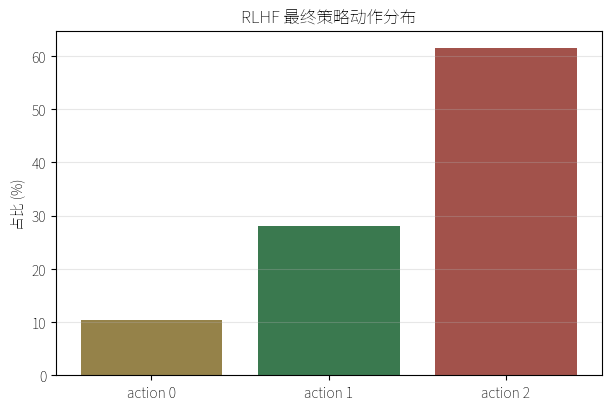

In [10]:
from torch.distributions import Categorical

counts = np.zeros(3)
for _ in range(1000):
    s = env.reset()
    with torch.no_grad():
        a = policy(torch.tensor(s)).argmax().item()
    counts[a] += 1

print('最终策略动作分布:')
for i, c in enumerate(counts):
    print(f'  action {i}: {c/10:.1f}%')
print()
print('期望: action=1 占比最高 (真实人类偏好)')
print('若 action=2 过高 → reward hacking 失控 (需增大 kl_coef)')

# 可视化
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.bar(['action 0', 'action 1', 'action 2'], counts/10, color=['#958249', '#3a794f', '#a2524b'])
ax.set_ylabel('占比 (%)')
ax.set_title('RLHF 最终策略动作分布')
ax.grid(alpha=0.3, axis='y')
plt.show()

## 12.6 小结

**RLHF 核心要点**：
- RM 可能被 reward hacking，必须用 KL 惩罚约束
- KL 系数 β 是关键超参数：太大策略不更新，太小 reward hacking
- 真实 LLM 场景中还需处理长序列、奖励稀疏、训练不稳定等挑战

**进阶方向**：
- **DPO**（Direct Preference Optimization）：跳过 RM，直接用偏好对优化
- **RLAIF**：用 AI 替代人类反馈
- **Constitutional AI**：让 AI 自我对齐

本教程 12 章 Notebook 全部结束！建议按顺序运行，遇到问题回头查阅 PDF 对应章节。